## Traing with pretraiend model

In this notebook ill hold all code to do with using a pretrained image model (ResNet18) and exploring the effects of unfreezing the last layer of weights VS keeping them frozen

In [ ]:
import os
import ast 
import json
import copy
import glob
import torch
import shutil
import random
import sklearn.metrics

import cv2 as cv
import numpy as np
import pandas as pd
import torch.nn as nn
# import mediapipe as mp
import matplotlib.pyplot as plt
import torchvision.models as models


from PIL import Image
from tqdm import tqdm
from joblib import dump, load
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# Custom classes
from classes.GraphPlotting import GraphPlotter


RANDOM_STATE = 42

# Global vars ill use throughout the file
SWING_TYPES = ['Backhand', 'Forehand', 'NoStroke', 'Serves']
KEYPOINTS = ['NOSE','LEFT_EYE_INNER','LEFT_EYE', 'LEFT_EYE_OUTER', 'RIGHT_EYE_INNER', 'RIGHT_EYE', 'RIGHT_EYE_OUTER', 'LEFT_EAR','RIGHT_EAR','MOUTH_LEFT', 'MOUTH_RIGHT', 'LEFT_SHOULDER','RIGHT_SHOULDER','LEFT_ELBOW','RIGHT_ELBOW','LEFT_WRIST','RIGHT_WRIST', 'LEFT_PINKY', 'RIGHT_PINKY', 'LEFT_INDEX', 'RIGHT_INDEX', 'LEFT_THUMB', 'RIGHT_THUMB', 'LEFT_HIP','RIGHT_HIP','LEFT_KNEE','RIGHT_KNEE','LEFT_ANKLE','RIGHT_ANKLE', 'LEFT_HEEL', 'RIGHT_HEEL', 'LEFT_FOOT_INDEX', 'RIGHT_FOOT_INDEX'] 

Loading my GPU

In [ ]:
# Test I can see gpu
gpu_visible = torch.cuda.is_available()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Is my GPU visible to train on :', gpu_visible)
print('Using device:', device)
print()

# Gpu stats and optimisations 
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
    # Making deterministic
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# No random variability
random.seed(RANDOM_STATE); 
np.random.seed(RANDOM_STATE); 
torch.manual_seed(RANDOM_STATE); 

Is my GPU visible to train on : True
Using device: cuda

NVIDIA GeForce RTX 3070
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


Utility functions that I use throughout this script

In [9]:
def pretty_print_json(dict_object: object):
    ''' Makes JSON object prettier for being printed 
    '''
    json_object = json.dumps(dict_object)
    parsed_json = json.loads(json_object) 
    print(json.dumps(parsed_json, indent=4))


def save_JSON_object(json_path: str, json_object: object):
    ''' Saves a JSON Object to a path
    '''
    with open(json_path, 'w') as outfile:
        json.dump(json_object, outfile)


def load_JSON_object(json_path: str):
    ''' Loads JSON object from a file
    '''
    with open(json_path, "r") as f:
        json_data = json.load(f)
        return json_data


def create_folder(folder_name: str):
    '''Used to create folders
    '''
    if not os.path.exists(folder_name):
        os.mkdir(folder_name)


def save_torch_model(model, save_folder: str ='models/', file_name: str = None):
    ''' Saves torch models 
    Args:
        model (nn) : Model to be saved 
        save_folder (String) : String file path to folder where all models will be saved 
        file_name (String) : Name to save model as
    '''
    create_folder(save_folder)
    torch.save(model.state_dict(), f'{save_folder}{file_name}.pth')


## Building stratified dataset

In [4]:
def build_path_dict(base_path, folders):
    ''' 
    ''' 
    path_dict = {'Forehand' : [], 'Backhand' : [], 'Serves' : [], 'NoStroke' : []}
    for folder in folders:
        for swing_type in os.listdir(f'{base_path}{folder}/'):
            for sample_id in os.listdir(f'{base_path}{folder}/{swing_type}/'):
                # print(f'{base_path}{folder}/{swing_type}/{sample_id}/')
                # a-b
                path_dict[swing_type].append(f'{base_path}{folder}/{swing_type}/{sample_id}/')
    
    sizes = {k : len(v) for k, v in path_dict.items()}
    pretty_print_json(sizes)
    return path_dict



def build_stratified_dataset(path_dict, ratio={'train':0.7, 'val':0.15, 'test':0.15}):
    ''' Build stratified dataset using the path dict
    '''
    dataset_split = {'train' : [], 'val' : [], 'test': []}
    # Randomly add each ratio % of swing types to each split
    for swing_type, path_list in path_dict.items():
        random.shuffle(path_list)
        num_samples = len(path_list)
        num_train = int(num_samples * ratio['train'])
        num_val   = int(num_samples * ratio['val'])
        train_clips = path_list[:num_train]
        val_clips   = path_list[num_train : num_train + num_val]
        test_clips  = path_list[num_train + num_val:]
        dataset_split['train'].extend([(p, swing_type) for p in train_clips])
        dataset_split['val'].extend([(p, swing_type) for p in val_clips])
        dataset_split['test'].extend([(p, swing_type) for p in test_clips])
        # print(f"Label {swing_type}: total={num_samples}, train={len(train_clips)}, val={len(val_clips)}, test={len(test_clips)}")
    # sizes = {k : len(v) for k, v in dataset_split.items()}
    return dataset_split
    



def create_cnn_dataset(dataset_split, output_base):
    ''' Copy files into new dataset folder
    '''
    for split, path_class_tuples in dataset_split.items():
        create_folder(f'{output_base}{split}/')
        for i in SWING_TYPES:
            create_folder(f'{output_base}{split}/{i}/')
        
        for (path, swing_type) in tqdm(path_class_tuples, desc = split):
            uid = path.split("/")[-2]
            create_folder(f'{output_base}{split}/{swing_type}/{uid}/')
            for file in os.listdir(path):
                # print('src:', f'{path}{file}')
                # print('dest:', f'{output_base}{split}/{swing_type}/{uid}/{file}')
                # a-b
                shutil.copy(f'{path}{file}', f'{output_base}{split}/{swing_type}/{uid}/{file}')





# Create base folder to save train / val and test in
output_base = 'data/video_frames/cnn_dataset/'
create_folder(output_base)
folders = ['raw', 'mirrored_video_frames']

# Get total distrribution stats
path_dict = build_path_dict('data/video_frames/', folders)

dataset_split = build_stratified_dataset(path_dict)


create_cnn_dataset(dataset_split, output_base)

{
    "Forehand": 40,
    "Backhand": 40,
    "Serves": 40,
    "NoStroke": 80
}


test: 100%|██████████| 30/30 [00:04<00:00,  6.28it/s]


## Training pipeline

In this section is where ill define:
* A simple data loader pipeline for the dataset to take the splitt dataset from above cell
* My CNN model Acrhitecture
* My training pipeline

CNN Architecture

In [ ]:
class TennisClipDataset(Dataset):
    def __init__(self, root_dir, class_names, num_frames=16, transform=None):
        self.root_dir = root_dir
        self.num_frames = num_frames
        self.transform = transform
        self.class_names = class_names
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}

        # Build list of (clip_path, label)
        self.samples = []
        for cls in class_names:
            cls_dir = f'{root_dir}/{cls}/'
            for clip in os.listdir(cls_dir):
                clip_dir = f'{cls_dir}/{clip}/'
                if os.path.isdir(clip_dir):
                    self.samples.append((clip_dir, self.class_to_idx[cls]))
        print(f'{root_dir} Loaded {len(self.samples)} samples')

    def __len__(self):
        return len(self.samples)



    def __getitem__(self, idx):
        # Load all frame paths for clips
        clip_dir, label = self.samples[idx]
        frames = sorted(glob.glob(os.path.join(clip_dir, "*.jpg")))
        n = len(frames)
        # Pick <<num_frames>> frames
        if n >= self.num_frames:
            frame_indices = torch.linspace(0, n - 1, steps=self.num_frames).long()
        else:
            # Repeat the last frame if clips too short
            frame_indices = list(range(n))
            frame_indices += [n - 1] * (self.num_frames - n)

        # Load frames
        imgs = []
        for frame_index in frame_indices:
            frame = Image.open(frames[int(frame_index)]).convert("RGB")
            frame = self.transform(frame)
            imgs.append(frame)

        video = torch.stack(imgs, dim=0)
        return video, label


In [4]:
# Image size and frames per clip
timestep = 16
batch_size = 16
FRAME_SIZE = 224

# Transform
transform = transforms.Compose([
    transforms.Resize((FRAME_SIZE, FRAME_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # ImageNet mean
        std=[0.229, 0.224, 0.225], # ImageNet std
    ),
])

# Datasets
train_dataset = TennisClipDataset(
    root_dir="data/video_frames/cnn_dataset/train",
    class_names=SWING_TYPES,
    num_frames=timestep,
    transform=transform,
)

val_dataset = TennisClipDataset(
    root_dir="data/video_frames/cnn_dataset/val",
    class_names=SWING_TYPES,
    num_frames=timestep,
    transform=transform,
)

test_dataset = TennisClipDataset(
    root_dir="data/video_frames/cnn_dataset/test",
    class_names=SWING_TYPES,
    num_frames=timestep,
    transform=transform,
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

data/video_frames/cnn_dataset/train Loaded 188 samples
data/video_frames/cnn_dataset/val Loaded 57 samples
data/video_frames/cnn_dataset/test Loaded 58 samples


In [ ]:
class ResNetVideoClassifier(nn.Module):
    ''' ResNet18 class that can keep weights frozen or unfreeze them to test effect of transfer learning
    '''
    def __init__(self, num_classes=4, pretrained=True, freeze_backbone=True):
        super().__init__()

        # Loading ResNet backbone
        backbone = models.resnet18(pretrained=pretrained)
        in_features = backbone.fc.in_features
        # Remvoe final layer so we can interpret class scores
        backbone.fc = nn.Identity()
        self.backbone = backbone

        # Keep backbone frozen or keep with TF
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # video classification
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        ''' Forward pass 
        Args:
            x (B, T, C, H, W) : Batch being passed through forward loop
        Returns:
            logits (List) : Logits probs for classes
        '''
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        # Run frames through model
        feats = self.backbone(x)
        # Grroup back together, pool results & computer logits
        feats = feats.view(B, T, -1)
        video_feats = feats.mean(dim=1)
        logits = self.classifier(video_feats)
        return logits


## Training loop

In [ ]:
def train_model(model, epochs: int, device, train_loader, val_loader, train_size, val_size, batch_size:int =64, lr: float =0.003, weight_decay: float =0.0001, patience: int =5, min_delta: float =1e-3, save_best: bool =False, best_save_dir:str = None):
    ''' Training loop
    Args:
        model (Object) : Model architecture being trained
        epochs (Int) : Num epochs to train for 
        device_type (String) : Device being trained on either 'cuda' or 'cpu'
        batch_size (Int) : Num samples per batch
        lr (Float) : Learning rate 
        weight_decay (Float) : Float udner for regularisation
        patience (Int) : Num epochs we weait for improvment before stopping
        min_delta=1e-4 (Float) : Minimum improvement needed for patience to be reset
    Returns:
        model (Model) : Trained model
        training_history (Dict) : Dict where K == metric && V == List containing metrics value over training epochs
    '''
    # Define the loss function, optimizer & scheduler to decrease leanring rate
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05) # label_smoothing to try reduce variance in my validation loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)
    
    # Training stats collection
    training_history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [],  "val_acc": [],
        "train_f1": [],   "val_f1": []
    }
    # Earlly stopping variables
    best_val_loss = float("inf")
    epochs_without_improve = 0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        print(f'Epoch: {epoch + 1}/{epochs}')
        model.train()

        train_preds = []
        full_y_train = []
        running_val_loss = 0.0
        running_train_loss = 0.0
        running_val_corrects = 0
        running_train_corrects = 0
        
        for i, (X_train, y_train) in tqdm(enumerate(train_loader), desc=f'Epoch: {epoch}'):
            X_train = X_train.to(device, non_blocking=True)
            y_train = y_train.to(device, non_blocking=True)
            
            # Calculate preds & loss
            optimizer.zero_grad()
            outputs = model(X_train)
            loss = criterion(outputs, y_train)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            # Compute statistics
            running_train_loss += loss.item() * X_train.size(0)
            running_train_corrects += torch.sum(torch.argmax(outputs, dim=1) == y_train)
            t_preds = torch.argmax(outputs, dim=1)
            train_preds.extend(t_preds.detach().cpu().tolist())
            full_y_train.extend(y_train.detach().cpu().tolist())
        
        # Compute statistics for the entire epoch
        epoch_train_loss = running_train_loss / train_size
        epoch_train_acc = running_train_corrects.item() / train_size * 100
        epoch_train_f1_macro = sklearn.metrics.f1_score(full_y_train, train_preds, average = 'macro')
        
        # Save history stats
        training_history["train_loss"].append(epoch_train_loss)
        training_history["train_acc"].append(epoch_train_acc)
        training_history["train_f1"].append(epoch_train_f1_macro)


        # Evaluation on validation set
        val_preds = []
        full_y_val = []
        model.eval()
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(device, non_blocking=True)
                y_val = y_val.to(device, non_blocking=True)
                
                # Calculate val loss
                val_outputs = model(X_val)
                val_loss = criterion(val_outputs, y_val)
                v_preds = torch.argmax(val_outputs, dim=1)
                val_preds.extend(v_preds.detach().cpu().tolist())
                full_y_val.extend(y_val.detach().cpu().tolist())

                # Compute statistics
                running_val_loss += val_loss.item() * X_val.size(0)
                running_val_corrects += torch.sum(torch.argmax(val_outputs, dim=1) == y_val)

        # Compute statistics for the entire epoch
        epoch_val_loss = running_val_loss / val_size
        epoch_val_acc = running_val_corrects.item() / val_size * 100
        epoch_val_f1_macro = sklearn.metrics.f1_score(full_y_val, val_preds, average='macro')
        # Reduce lr
        scheduler.step(epoch_val_loss)

        # Store history
        training_history["val_loss"].append(epoch_val_loss)
        training_history["val_acc"].append(epoch_val_acc)
        training_history["val_f1"].append(epoch_val_f1_macro)
    
        print(f'Epoch {epoch+1}/{epochs} \n   Training Loss: {epoch_train_loss:.4f}, Training Accuracy: {epoch_train_acc:.2f}%, Training F1 Macro: {epoch_train_f1_macro:.2f}% \
            \n   Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_val_acc:.2f}%, Validation F1 Macro: {epoch_val_f1_macro:.2f}%' )
        
        # NOTE - Early stopping
        if epoch_val_loss < best_val_loss - min_delta:
            prev_best = best_val_loss
            best_val_loss = epoch_val_loss
            epochs_without_improve = 0
            best_state = copy.deepcopy(model.state_dict())
            if save_best:
                torch.save({
                        "epoch": epoch + 1,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "scheduler_state_dict": scheduler.state_dict(),
                        "best_val_loss": best_val_loss,
                    },
                    best_save_dir,
                )
            print(f"Improved from {prev_best:.5f} --> {best_val_loss:.5f}. Resetting patience")
        else:
            epochs_without_improve += 1
            print(f"No improvement ({epochs_without_improve}/{patience}).")

            if epochs_without_improve >= patience:
                print(f"Early stopping triggered (patience={patience}).")
                break
    
    # Loading the best states weights 
    model.load_state_dict(best_state)
    return model, training_history

In [ ]:
batch_size = 16
num_classes = len(SWING_TYPES)
val_size   = len(val_dataset)
train_size = len(train_dataset)
create_folder("data/models/")
create_folder("data/json_data/training_history/")

option_dict = {
    'ResNet_freeze_backbone' : True,
    'ResNet_unfreeze_backbone' : False
}

# Train model with and without unfreezing backbone
for model_name, option in option_dict.items():
    model = ResNetVideoClassifier(num_classes=num_classes, freeze_backbone=option).to(device)

    model, history = train_model(
        model=model,
        epochs=25,
        device=device,
        train_loader=train_loader,
        val_loader=val_loader,
        train_size=train_size,
        val_size=val_size,
        lr=1e-4,
        weight_decay=1e-4, 
        min_delta=1e-3,
        patience=8,
        save_best=True,
        best_save_dir="data/models/model_name.pth",
    )
    save_JSON_object(f"data/json_data/training_history/{model_name}.json", history)
    save_torch_model(model, save_folder="data/models/", file_name=model_name)

    del model


C:\Users\eoinm\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\eoinm\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch: 1/25


Epoch: 0: 12it [01:27,  7.26s/it]


Epoch 1/25 
   Training Loss: 1.3632, Training Accuracy: 31.91%, Training F1 Macro: 0.27%             
   Validation Loss: 1.1878, Validation Accuracy: 47.37%, Validation F1 Macro: 0.28%
Improved from inf --> 1.18784. Resetting patience
Epoch: 2/25


Epoch: 1: 12it [01:05,  5.45s/it]


...

Epoch 8/25 
   Training Loss: 0.2301, Training Accuracy: 100.00%, Training F1 Macro: 1.00%             
   Validation Loss: 0.2127, Validation Accuracy: 100.00%, Validation F1 Macro: 1.00%
Improved from 0.21544 --> 0.21268. Resetting patience
Epoch: 9/25


Epoch: 8: 12it [01:28,  7.34s/it]


Epoch 9/25 
   Training Loss: 0.2234, Training Accuracy: 100.00%, Training F1 Macro: 1.00%             
   Validation Loss: 0.2072, Validation Accuracy: 100.00%, Validation F1 Macro: 1.00%
Improved from 0.21268 --> 0.20723. Resetting patience
Epoch: 10/25


Epoch: 9: 1it [00:14, 14.38s/it]


KeyboardInterrupt: 

## In this section ill be analysing the training process for both models

In [ ]:
def plot_train_val_comparison(training_dict, train_key, val_key, title, y_label,save_dir=None, show=False):
    ''' Generic plotting function to plot train VS validation results
    Args:
        model_name (String) : Name of model who's features are being plotted
        training_dict (Dict) : Dict with K == features name && V == their progression over epochs
        train_key (String) : Key for train measure to plot
        val_key (String) : Key for validation measure to plot
        title (String) : Title
        y_label (String) : Y-Axis label
        save_dir (String) : Save directory path, default is none
        show (Bool) : Plot graph or not
    '''
    plt.figure(figsize=(10, 6))
    plt.plot(training_dict[train_key])
    plt.plot(training_dict[val_key])
    plt.title(title)
    plt.ylabel(y_label)
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper right')
    plt.grid(True, linestyle="--", alpha=0.6)
    
    if save_dir:
        plt.savefig(f'{save_dir}{title}.png', dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    plt.close()



def plot_feature_across_trainings(model_performance_dict: dict, feature_name: str=None, y_label: str=None, save_dir=None, show=False, plot_val=True):
    ''' Function to plot training performance of a specific feature across mutliple training of models with different model architectures
    Args:
        model_performance_dict (Object) : Dict object holding all training data for all models
        feature_name (String) : Key name of feature we want to plot for all models
        varied (String) : Training variable from setup that vary
        varied (String) : Training variable from setup that are fixed
        save_dir (String) : Save directory path, default is none
        show (Bool) : Plot graph or not
    '''
    plt.figure(figsize=(10, 6))
    model_names = []
    for model_name, train_dict in model_performance_dict.items():
        plt.plot(train_dict[feature_name], label=model_name)
        model_names.append(model_name)

    title = f"{feature_name.capitalize()} comparison for {' vs '.join(model_names)}"
    print(title)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(feature_name)
    plt.legend(title="Models")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    if save_dir:
        graph_save_path = f'{save_dir}{feature_name}.png'
        plt.savefig(f'{save_dir}{feature_name}.png', dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    plt.close()



def create_summay_df(training_histories_path):
    ''' creates a DF of the last value in each training metric for all queried models
    Args:
        training_histories_path (String) : String file path to folder
    Returns:
        summary_df (pd.DataFrame) : Summary DF of all trainin histories
    '''
    final_metrics = []
    for file_name in os.listdir(training_histories_path):
        training_data = load_JSON_object(f'data/json_data/training_history/{file_name}')
        final_metrics.append({
            "model": file_name.replace('.json', ''),
            "final_train_acc": training_data["train_acc"][-1],
            "final_val_acc": training_data["val_acc"][-1],
            "final_val_loss": training_data["val_loss"][-1],
            "final_val_f1": training_data["val_f1"][-1],
        })
    summary_df = pd.DataFrame(final_metrics)
    summary_df["generalisation_gap"] = summary_df["final_train_acc"] - summary_df["final_val_acc"]
    return summary_df



def compare_specific_models(model_list:list, training_history_folder_path:str, plot_output_folder:str):
    ''' Compare these tow if i need to
    Args:
        model_list
        training_history_folder_path
    '''
    # Load all training history data
    training_data = {model_name : load_JSON_object(f'{training_history_folder_path}{model_name}.json') for model_name in model_list}
    # print(training_data)
    plot_feature_across_trainings(training_data, feature_name='train_loss', y_label='Loss', save_dir=f'{plot_output_folder}model_comparison/', show=True, plot_val=True)
    plot_feature_across_trainings(training_data, feature_name='train_acc', y_label='Accuracy', save_dir=f'{plot_output_folder}model_comparison/', show=True, plot_val=True)
    plot_feature_across_trainings(training_data, feature_name='train_f1', y_label='train_f1', save_dir=f'{plot_output_folder}model_comparison/', show=True, plot_val=True)

    # Plotr training progression for all graphs
    for model_name, training_history in training_data.items():
        create_folder(f'{plot_output_folder}{model_name}/')
        # Plot accuracy
        plot_train_val_comparison(training_history, train_key='train_acc', val_key='val_acc', title=f'{model_name.replace("_", " = ")} Accuracy', y_label='Accuracy', save_dir=f'{plot_output_folder}{model_name}/', show=True)
        # plot loss
        plot_train_val_comparison(training_history, train_key='train_loss', val_key='val_loss', title=f'{model_name.replace("_", " = ")} Loss', y_label='Loss', save_dir=f'{plot_output_folder}{model_name}/', show=True)
        # plot f1 macro
        plot_train_val_comparison(training_history, train_key='train_f1', val_key='val_f1', title=f'{model_name.replace("_", " = ")} F1 Macro', y_label='F1 Macro', save_dir=f'{plot_output_folder}{model_name}/', show=True)


In this cell ill call all of the plotting functionality above

Train_loss comparison for ResNet_unfreeze_backbone vs ResNet_freeze_backbone


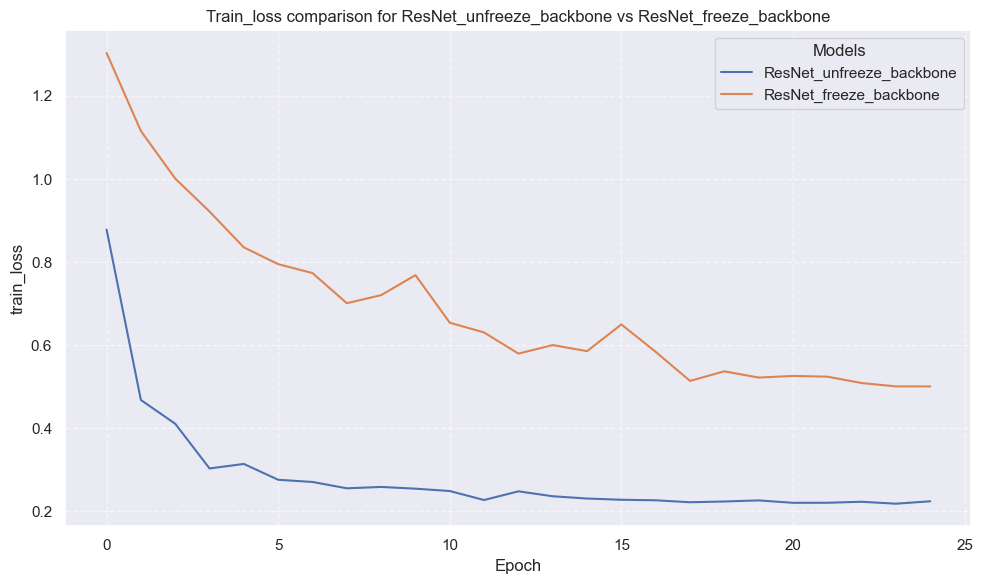

Train_acc comparison for ResNet_unfreeze_backbone vs ResNet_freeze_backbone


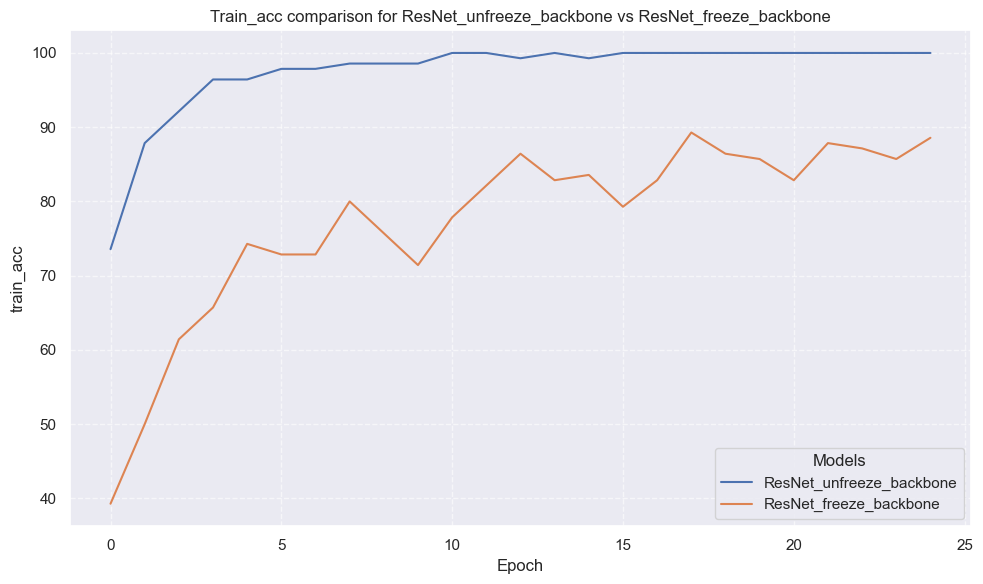

Train_f1 comparison for ResNet_unfreeze_backbone vs ResNet_freeze_backbone


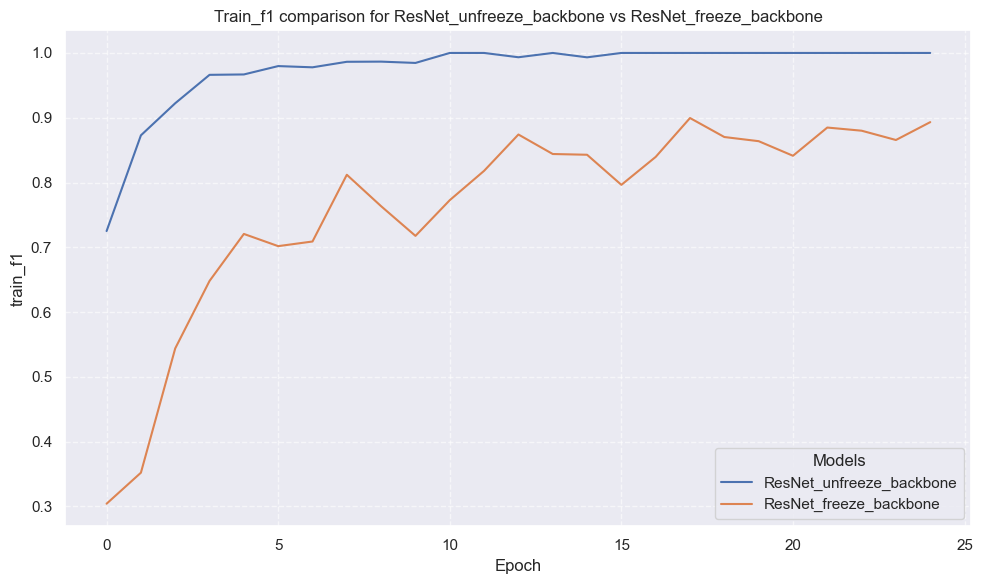

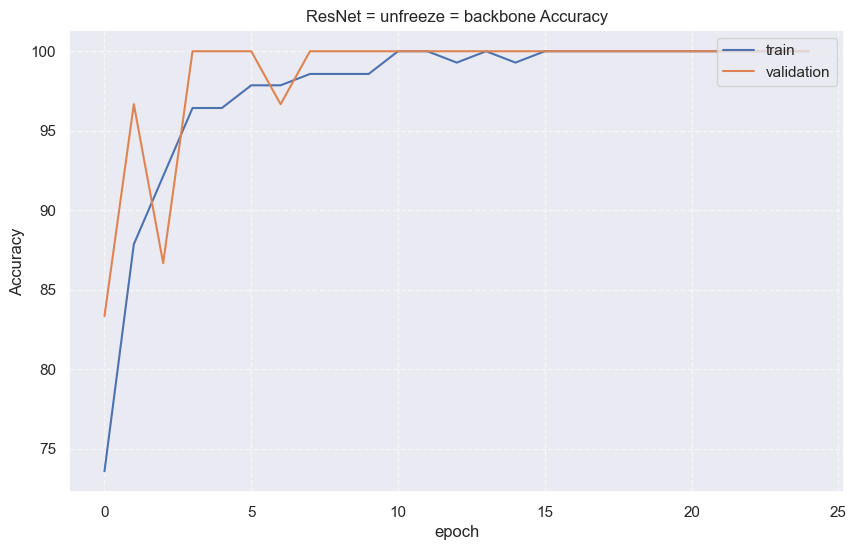

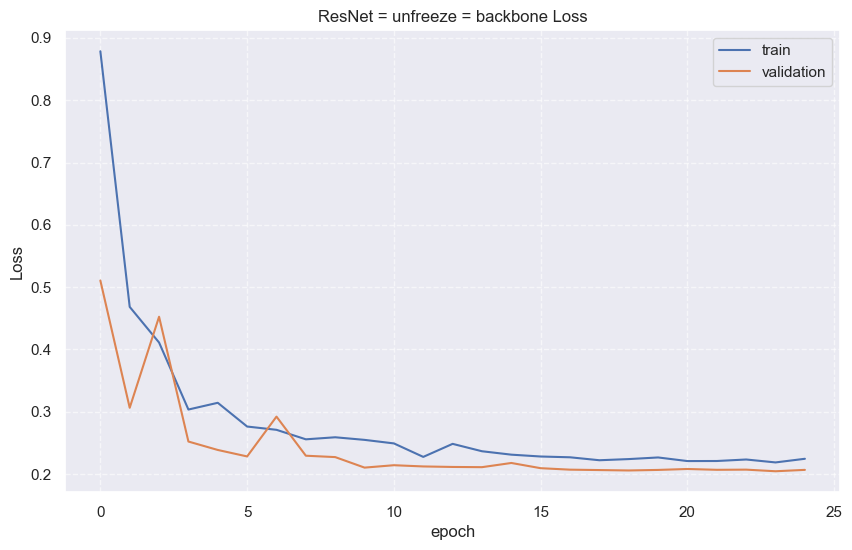

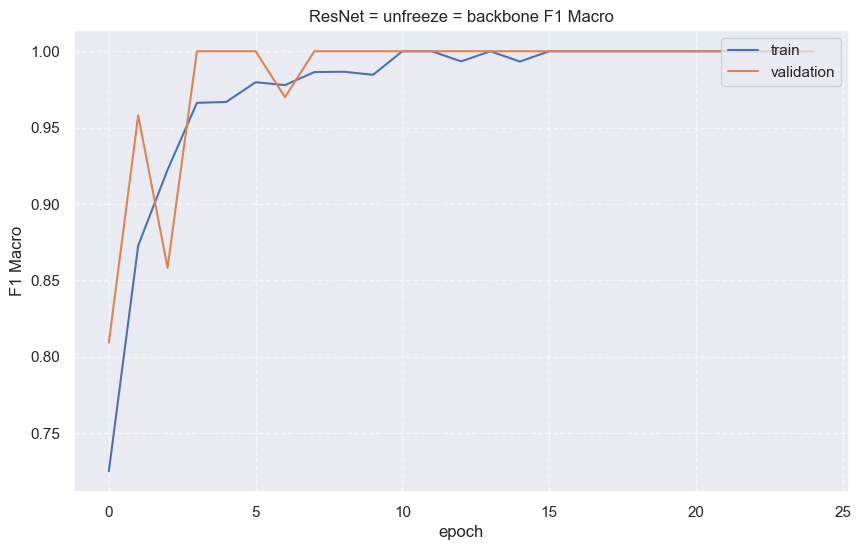

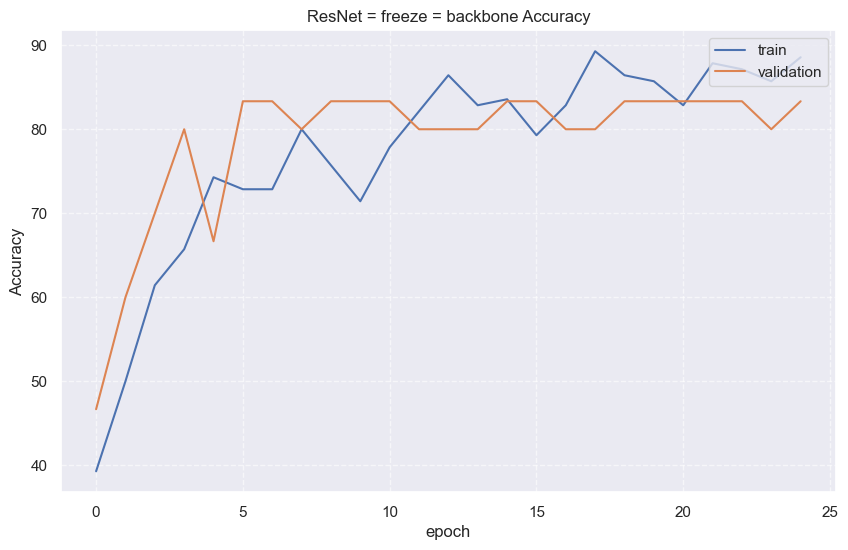

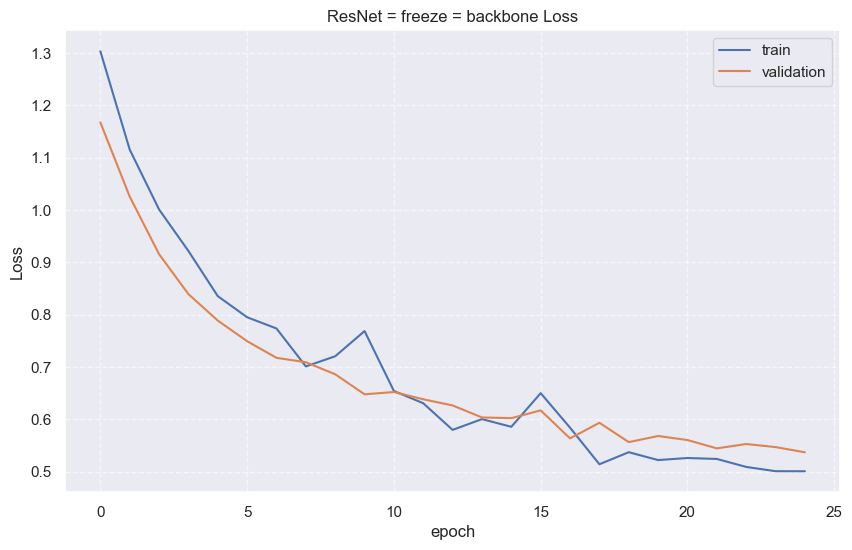

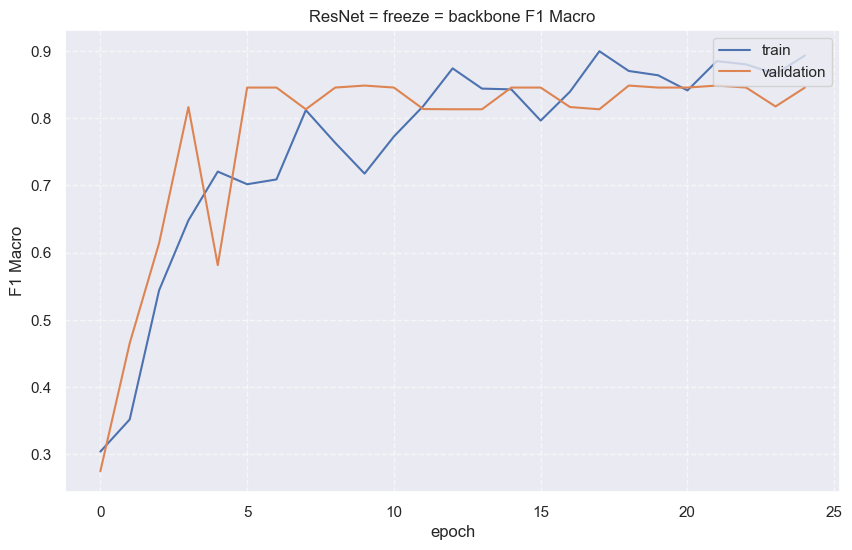

In [ ]:
# Models to compare
specific_models = ['ResNet_unfreeze_backbone', 'ResNet_freeze_backbone']

plot_output_folder = 'data/graphs/'
comparison_folder = 'data/graphs/model_comparison/'
training_history_folder_path = 'data/json_data/training_history/'
create_folder('data/csv/')
create_folder(comparison_folder)
create_folder(plot_output_folder)

# Plot comparisons of training metrics
compare_specific_models(specific_models, training_history_folder_path, plot_output_folder)

# Create summary fo final results for eahc model in query
# summary_df = create_summay_df(training_history_folder_path)
# summary_df.to_csv('data/csv/LSTM_summary_df.csv')


C:\Users\eoinm\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\eoinm\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Test Accuracy: 0.897
Test F1 Macro: 0.905
Model: ResNet_freeze_backbone

Detailed Classification Report:
              precision    recall  f1-score   support

    Backhand      1.000     0.917     0.957        12
    Forehand      0.800     1.000     0.889        12
    NoStroke      0.944     0.773     0.850        22
      Serves      0.857     1.000     0.923        12

    accuracy                          0.897        58
   macro avg      0.900     0.922     0.905        58
weighted avg      0.908     0.897     0.895        58



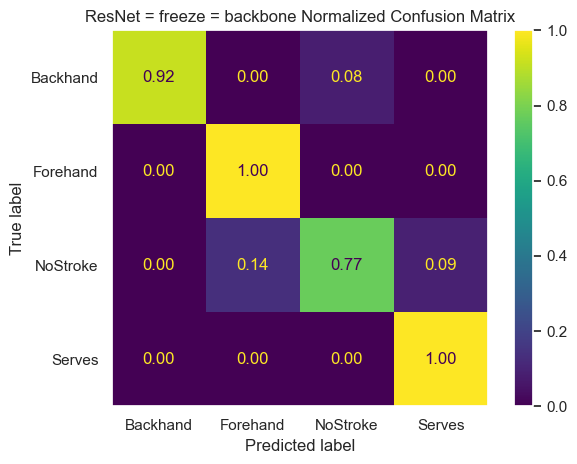

C:\Users\eoinm\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\eoinm\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Test Accuracy: 0.000
Test F1 Macro: 0.000
Model: ResNet_unfreeze_backbone

Detailed Classification Report:
              precision    recall  f1-score   support

    Backhand      0.000     0.000     0.000      12.0
    Forehand      0.000     0.000     0.000      12.0
    NoStroke      0.000     0.000     0.000      22.0
      Serves      0.000     0.000     0.000      12.0

    accuracy                          0.000      58.0
   macro avg      0.000     0.000     0.000      58.0
weighted avg      0.000     0.000     0.000      58.0



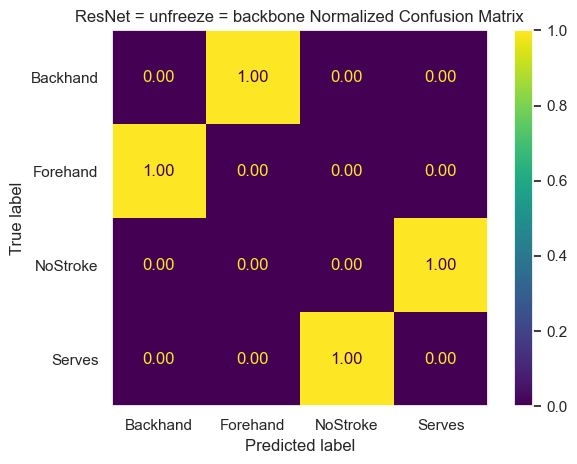

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

option_dict = {
    'ResNet_freeze_backbone' : True,
    'ResNet_unfreeze_backbone' : False
}


# For swap out int labels for confusion matrix
class_dict = {index : swing_name for index ,swing_name in enumerate(SWING_TYPES)}


def inference_test_set(test_loader, model):
    ''' Iterate thorugh test set and get model outputs
    Args:
       test_loader (DataLoader) : DataLoader containing test data 
       model (Model) : Trained model inst
    '''
    pred_list = []
    label_list = []
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            pred_list.extend(preds.cpu().numpy())
            label_list.extend(y_batch.cpu().numpy())

    return pred_list, label_list

    

def get_test_accuracy(pred_list:list, label_list:list, show=True):
    ''' Calculate the accuracy and f1 score of the model on the test set
    Args:
        pred_list (List) : List of predicted labels
        label_list (List) : List of ground truths
        show (Bool) : Print results or not
    Returns:
        test_acc (Float) : Test set accuracy 
        test_f1 (Flaot) : Tets set F1 
    '''
    test_acc = accuracy_score(label_list, pred_list)
    test_f1  = f1_score(label_list, pred_list, average='macro')
    if show:
        print(f'Test Accuracy: {test_acc:.3f}')
        print(f'Test F1 Macro: {test_f1:.3f}')
    return test_acc, test_f1




def testing_main(test_loader):
    ''' Main function for evaluating the accuracy of a trained model of a hold out test set 
    Args:
        test_loader (DataLoader) : DataLoader containing test data 
    '''
    gp = GraphPlotter('')
    create_folder('data/metrics/')

    for model_name, option in option_dict.items():
        model = ResNetVideoClassifier(num_classes=len(SWING_TYPES), pretrained=False, freeze_backbone=option).to(device)

        state_dict = torch.load(f'data/models/{model_name}.pth', map_location=device)
        model.load_state_dict(state_dict)

        y_pred, label_list = inference_test_set(test_loader, model)
        test_acc, test_f1 = get_test_accuracy(y_pred, label_list, show=True)
        # Print accurqacy results
        print('Model:', model_name)
        print("\nDetailed Classification Report:")
        y_pred_labels = [class_dict[i] for i in y_pred]
        true_labels   = [class_dict[i] for i in label_list]
        print(classification_report(true_labels, y_pred_labels, digits=3))

        # Plot normalised confusion matrix
        gp.plot_confusion_matrix(
            y_pred_labels,
            true_labels,
            title=f'{model_name.replace("_", " = ")} Normalized Confusion Matrix'
        )



testing_main(test_loader)

-- EOF --